# nanoGPT-modern — end-to-end LLM training
**Modern LLaMA-style stack:** RoPE · RMSNorm · SwiGLU · BPE tokenizer

Run cells top-to-bottom. After any kernel restart, just run all cells again — checkpoints handle resuming.

| Cell | Purpose |
|------|---------|
| 1 | Verify GPU |
| 2 | Install deps |
| 3 | Config (single source of truth) |
| 4 | Download + tokenize TinyStories |
| 5 | Model definition |
| 6 | Dataloader |
| 7 | Training loop (auto-resumes from checkpoint) |
| 8 | Generate text |
| 9 | Plot loss curve |

In [1]:
# ═══════════════════════════════════════════════════════════════════
# CELL 1 — Verify GPU
# ═══════════════════════════════════════════════════════════════════
import torch

assert torch.cuda.is_available(), "No GPU found — enable GPU in Settings → Accelerator"

n_gpus = torch.cuda.device_count()
for i in range(n_gpus):
    props = torch.cuda.get_device_properties(i)
    print(f"GPU {i}: {props.name} — {props.total_memory/1e9:.1f}GB VRAM")

print(f"\nPyTorch {torch.__version__}")
print(f"BF16 supported: {torch.cuda.is_bf16_supported()}")

# T4 supports FP16 but not BF16 — we'll use FP16
# A100/H100 support BF16 which is more numerically stable
DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
print(f"Using dtype: {DTYPE}")

GPU 0: Tesla T4 — 15.6GB VRAM
GPU 1: Tesla T4 — 15.6GB VRAM

PyTorch 2.10.0+cu128
BF16 supported: True
Using dtype: torch.bfloat16


In [2]:
# ═══════════════════════════════════════════════════════════════════
# CELL 2 — Install dependencies
# ═══════════════════════════════════════════════════════════════════
import subprocess, sys

pkgs = ["tiktoken", "regex", "matplotlib"]
for pkg in pkgs:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg])

import tiktoken, regex, matplotlib
print("All dependencies ready")

All dependencies ready


In [3]:
# ═══════════════════════════════════════════════════════════════════
# CELL 3 — Config (single source of truth)
# ═══════════════════════════════════════════════════════════════════
# Every hyperparameter lives here. Change here, everything else updates.
# This also fixes the kernel-restart problem: config is always re-defined
# when you run top-to-bottom.

import os, torch

config = dict(
    # ── model architecture ──────────────────────────────────────
    vocab_size  = 50257,   # GPT-2 tiktoken vocab size
    d_model     = 512,     # embedding dimension
    n_heads     = 8,       # attention heads (head_dim = 512/8 = 64)
    n_layers    = 6,       # transformer blocks
    max_seq     = 256,     # context window
    dropout     = 0.1,     # dropout probability

    # ── training ────────────────────────────────────────────────
    batch_size      = 8,      # sequences per batch
    grad_accum      = 16,       # gradient accumulation steps
                               # effective batch = 32 * 4 = 128 sequences
    max_steps       = 10000,   # total training steps
    learning_rate   = 3e-4,    # peak LR (cosine schedule decays to min_lr)
    min_lr          = 3e-5,    # minimum LR floor (= lr/10)
    warmup_steps    = 200,     # linear warmup before cosine decay
    weight_decay    = 0.1,     # AdamW weight decay
    grad_clip       = 1.0,     # gradient norm clip threshold
    beta1           = 0.9,
    beta2           = 0.95,    # slightly lower than default for LLMs

    # ── checkpointing ───────────────────────────────────────────
    ckpt_dir        = "/kaggle/working/checkpoints",
    ckpt_interval   = 500,     # save every N steps

    # ── evaluation ──────────────────────────────────────────────
    eval_interval   = 250,     # evaluate val loss every N steps
    eval_steps      = 50,      # number of batches for val loss estimate

    # ── data ────────────────────────────────────────────────────
    data_path       = "/kaggle/working/train.bin",
    val_split       = 0.005,   # 0.5% of data for validation
)

# derived values
config['device']        = 'cuda' if torch.cuda.is_available() else 'cpu'
config['dtype']         = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
config['effective_bs']  = config['batch_size'] * config['grad_accum']

os.makedirs(config['ckpt_dir'], exist_ok=True)

print("Config:")
for k, v in config.items():
    print(f"  {k:20s}: {v}")

Config:
  vocab_size          : 50257
  d_model             : 512
  n_heads             : 8
  n_layers            : 6
  max_seq             : 256
  dropout             : 0.1
  batch_size          : 8
  grad_accum          : 16
  max_steps           : 10000
  learning_rate       : 0.0003
  min_lr              : 3e-05
  warmup_steps        : 200
  weight_decay        : 0.1
  grad_clip           : 1.0
  beta1               : 0.9
  beta2               : 0.95
  ckpt_dir            : /kaggle/working/checkpoints
  ckpt_interval       : 500
  eval_interval       : 250
  eval_steps          : 50
  data_path           : /kaggle/working/train.bin
  val_split           : 0.005
  device              : cuda
  dtype               : torch.bfloat16
  effective_bs        : 128


In [4]:
# ═══════════════════════════════════════════════════════════════════
# CELL 4 — Download + tokenize TinyStories
# Skips automatically if train.bin already exists
# ═══════════════════════════════════════════════════════════════════
import os, numpy as np, tiktoken
from datasets import load_dataset

data_path = config['data_path']

if os.path.exists(data_path):
    tokens = np.memmap(data_path, dtype=np.uint16, mode='r')
    print(f"train.bin already exists — {len(tokens):,} tokens")
    print("Skipping download and tokenization")
else:
    print("Downloading TinyStories (~2GB, takes ~3 mins)...")
    dataset = load_dataset("roneneldan/TinyStories", split="train")
    print(f"Stories: {len(dataset):,}")

    # GPT-2 tiktoken — 50257 tokens, byte-level BPE
    # We use tiktoken here for speed; in llm-from-scratch we built our own
    enc = tiktoken.get_encoding("gpt2")
    eot = enc.eot_token   # end-of-text token = 50256, separates stories

    print("Tokenizing...")
    all_tokens = []
    for i, story in enumerate(dataset):
        # encode story + append end-of-text token as story separator
        toks = enc.encode_ordinary(story['text']) + [eot]
        all_tokens.extend(toks)
        if i % 50000 == 0:
            print(f"  {i:,}/{len(dataset):,} stories — {len(all_tokens):,} tokens")

    # save as uint16 (max value 65535, GPT-2 vocab fits in uint16)
    # uint16 vs int32 = 2x smaller file = faster I/O during training
    arr = np.array(all_tokens, dtype=np.uint16)
    arr.tofile(data_path)
    print(f"\nSaved {len(arr):,} tokens to {data_path}")
    print(f"File size: {os.path.getsize(data_path)/1e6:.0f}MB")
    del dataset, all_tokens, arr

# verify
tokens = np.memmap(data_path, dtype=np.uint16, mode='r')
n_val   = int(len(tokens) * config['val_split'])
n_train = len(tokens) - n_val
print(f"\nTrain tokens: {n_train:,}")
print(f"Val tokens:   {n_val:,}")
del tokens

train.bin already exists — 473,992,236 tokens
Skipping download and tokenization

Train tokens: 471,622,275
Val tokens:   2,369,961


In [5]:
# ═══════════════════════════════════════════════════════════════════
# CELL 5 — Model definition
# Modern LLaMA-style stack: RMSNorm + RoPE + SwiGLU
# ═══════════════════════════════════════════════════════════════════
import torch, torch.nn as nn, torch.nn.functional as F, math

import inspect

# write this entire cell to disk so we can reload after restart
with open('/kaggle/working/model.py', 'w') as f:
    f.write("import torch, torch.nn as nn, torch.nn.functional as F, math\n\n")
    # then the rest of your model classes

# ── RMSNorm ──────────────────────────────────────────────────────────
# Simpler than LayerNorm: normalise by RMS, no mean subtraction, no bias.
# Used in: LLaMA, Mistral, Gemma — ~10% faster than LayerNorm.
class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps    = eps
        self.weight = nn.Parameter(torch.ones(dim))   # learnable scale γ

    def forward(self, x):
        # x: [B, T, dim]
        # rms = sqrt(mean(x²) + eps) — shape [B, T, 1] for broadcasting
        rms = x.pow(2).mean(dim=-1, keepdim=True).add(self.eps).sqrt()
        return (x / rms) * self.weight


# ── RoPE ─────────────────────────────────────────────────────────────
# Rotary Position Embedding: rotates Q and K by position-dependent angles.
# Key property: dot(Q_rotated_pos_m, K_rotated_pos_n) depends only on
# relative distance (m-n), not absolute positions.
# Used in: LLaMA, Mistral, Gemma, Qwen — generalises to longer sequences.

def precompute_freqs(head_dim, max_seq, base=10000.0):
    """
    Precompute cos/sin frequencies once at init — not every forward pass.
    Returns cos, sin each of shape [max_seq, head_dim/2]

    head_dim/2 because we rotate PAIRS of dimensions:
      pair 0 (dims 0,1)  → fast frequency θ₀ = 1.0
      pair 1 (dims 2,3)  → slower    θ₁ = 1/10000^(2/head_dim)
      ...
      pair n (last pair) → slowest   period ~628k tokens
    Together they uniquely encode any position up to ~628k tokens.
    """
    # θᵢ = 1 / (base ^ (2i / head_dim)) — geometric sequence of frequencies
    theta = 1.0 / (base ** (torch.arange(0, head_dim, 2).float() / head_dim))
    t     = torch.arange(max_seq)                    # position indices [0..max_seq-1]
    freqs = torch.outer(t, theta)                    # [max_seq, head_dim/2]
    return freqs.cos(), freqs.sin()

def apply_rope(x, cos, sin):
    """
    Apply rotary embeddings to x (Q or K tensor).
    x: [B, n_heads, T, head_dim]

    Rotation formula for each pair (x_even, x_odd):
      x_rot_even = x_even*cos - x_odd*sin
      x_rot_odd  = x_even*sin + x_odd*cos
    """
    T   = x.shape[2]
    cos = cos[:T].unsqueeze(0).unsqueeze(0)          # [1, 1, T, head_dim/2]
    sin = sin[:T].unsqueeze(0).unsqueeze(0)

    x1  = x[..., ::2]                               # even dims: [B, H, T, head_dim/2]
    x2  = x[..., 1::2]                              # odd  dims: [B, H, T, head_dim/2]

    # rotate and interleave back to [B, H, T, head_dim]
    x_rot = torch.stack([-x2, x1], dim=-1).flatten(-2)
    return x * cos.repeat_interleave(2, -1) + x_rot * sin.repeat_interleave(2, -1)


# ── Causal Self-Attention ─────────────────────────────────────────────
# Multi-head attention with RoPE on Q and K (not V).
# is_causal=True in scaled_dot_product_attention handles the causal mask
# and uses FlashAttention automatically when available.
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.0):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads  = n_heads
        self.head_dim = d_model // n_heads

        # Q, K, V projections — no bias (RMSNorm before us handles mean)
        self.q_proj   = nn.Linear(d_model, d_model, bias=False)
        self.k_proj   = nn.Linear(d_model, d_model, bias=False)
        self.v_proj   = nn.Linear(d_model, d_model, bias=False)
        self.out_proj = nn.Linear(d_model, d_model, bias=False)
        self.dropout  = dropout

    def forward(self, x, cos, sin):
        B, T, C = x.shape

        # project and reshape: [B, T, C] → [B, n_heads, T, head_dim]
        def split_heads(t):
            return t.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)

        q = split_heads(self.q_proj(x))
        k = split_heads(self.k_proj(x))
        v = split_heads(self.v_proj(x))

        # apply RoPE to Q and K only — position affects similarity, not values
        q = apply_rope(q, cos, sin)
        k = apply_rope(k, cos, sin)

        # FlashAttention via PyTorch 2.0 — handles causal mask, dropout, scaling
        y = F.scaled_dot_product_attention(
            q, k, v,
            dropout_p=self.dropout if self.training else 0.0,
            is_causal=True
        )

        # merge heads: [B, n_heads, T, head_dim] → [B, T, C]
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        return self.out_proj(y)


# ── SwiGLU FFN ───────────────────────────────────────────────────────
# Replaces GELU FFN from GPT-2. Uses multiplicative gating:
#   output = down(SiLU(gate(x)) ⊗ up(x))
# Three matrices instead of two, d_ff = 2/3 * 4 * d_model
# (keeps param count equal to 4× FFN).
# Used in: LLaMA, PaLM, Mistral — consistently better than GELU.
class SwiGLU(nn.Module):
    def __init__(self, d_model, d_ff=None):
        super().__init__()
        if d_ff is None:
            d_ff = int(2/3 * 4 * d_model)  # 2/3 factor compensates for 3 matrices
            d_ff = (d_ff + 63) // 64 * 64  # round to multiple of 64 (GPU efficiency)
        self.gate = nn.Linear(d_model, d_ff, bias=False)  # gate path
        self.up   = nn.Linear(d_model, d_ff, bias=False)  # value path
        self.down = nn.Linear(d_ff, d_model, bias=False)  # projection back

    def forward(self, x):
        # SiLU(gate) acts as a smooth gate that controls which features pass through
        return self.down(F.silu(self.gate(x)) * self.up(x))


# ── Transformer Block ─────────────────────────────────────────────────
# Pre-norm architecture: RMSNorm BEFORE attention and FFN, not after.
# Pre-norm is more stable than post-norm for deep networks.
# Residual connections: x = x + sublayer(norm(x))
class Block(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.0):
        super().__init__()
        self.norm1 = RMSNorm(d_model)                          # pre-norm before attention
        self.attn  = CausalSelfAttention(d_model, n_heads, dropout)
        self.norm2 = RMSNorm(d_model)                          # pre-norm before FFN
        self.ffn   = SwiGLU(d_model)

    def forward(self, x, cos, sin):
        x = x + self.attn(self.norm1(x), cos, sin)  # attention sublayer + residual
        x = x + self.ffn(self.norm2(x))              # FFN sublayer + residual
        return x


# ── Full GPT Model ────────────────────────────────────────────────────
class NanoGPT(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers,
                 max_seq, dropout=0.0):
        super().__init__()
        self.max_seq = max_seq

        self.tok_emb = nn.Embedding(vocab_size, d_model)  # token → vector
        self.drop    = nn.Dropout(dropout)
        self.blocks  = nn.ModuleList([
            Block(d_model, n_heads, dropout) for _ in range(n_layers)
        ])
        self.norm    = RMSNorm(d_model)                   # final norm before lm_head
        self.lm_head = nn.Linear(vocab_size, vocab_size, bias=False)

        # weight tying: lm_head shares weights with tok_emb
        # rationale: input and output embeddings represent the same token space
        # saves vocab_size * d_model params (~25M for GPT-2 vocab)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.lm_head.weight = self.tok_emb.weight

        # precompute RoPE frequencies once — stored as buffers (not params)
        # buffers move to GPU with .to(device) but don't get gradients
        cos, sin = precompute_freqs(d_model // n_heads, max_seq)
        self.register_buffer("cos", cos)
        self.register_buffer("sin", sin)

        # weight initialisation
        self.apply(self._init_weights)

        # special scaled init for residual projections (GPT-2 paper)
        # rationale: residual stream grows by sqrt(n_layers) without this
        # scaling by 1/sqrt(2*n_layers) keeps variance stable at any depth
        for name, p in self.named_parameters():
            if name.endswith('out_proj.weight') or name.endswith('down.weight'):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * n_layers))

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        B, T = idx.shape
        assert T <= self.max_seq, f"Input length {T} > max_seq {self.max_seq}"

        x = self.drop(self.tok_emb(idx))    # [B, T, d_model]
        for block in self.blocks:
            x = block(x, self.cos, self.sin)
        x = self.norm(x)
        logits = self.lm_head(x)            # [B, T, vocab_size]

        loss = None
        if targets is not None:
            # flatten for cross entropy: [B*T, vocab] vs [B*T]
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1),
                ignore_index=-1  # ignore padding tokens
            )
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=50):
        """
        Autoregressive generation with temperature + top-k sampling.
        temperature > 1 → more random, < 1 → more deterministic
        top_k: only sample from top-k most likely tokens
        """
        self.eval()
        for _ in range(max_new_tokens):
            # crop to max_seq context window if needed
            idx_cond = idx[:, -self.max_seq:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature    # last token logits

            # top-k: zero out all logits below the k-th largest
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = float('-inf')

            probs    = F.softmax(logits, dim=-1)
            next_tok = torch.multinomial(probs, num_samples=1)
            idx      = torch.cat([idx, next_tok], dim=1)
        return idx


# ── Instantiate model ─────────────────────────────────────────────────
device = config['device']
model  = NanoGPT(
    vocab_size = config['vocab_size'],
    d_model    = config['d_model'],
    n_heads    = config['n_heads'],
    n_layers   = config['n_layers'],
    max_seq    = config['max_seq'],
    dropout    = config['dropout'],
).to(device)

# compile model — PyTorch 2.0+ fuses ops for ~20% speedup on T4
# comment out if you get errors
try:
    model = torch.compile(model)
    print("Model compiled (torch.compile)")
except Exception as e:
    print(f"Skipping compile: {e}")

total = sum(p.numel() for p in model.parameters())
print(f"\nParameters: {total/1e6:.1f}M")

# quick forward pass sanity check
dummy = torch.randint(0, config['vocab_size'], (2, 16)).to(device)
with torch.no_grad():
    logits, loss = model(dummy, dummy)
print(f"Forward pass OK — logits: {logits.shape}, loss: {loss.item():.4f}")
print(f"Expected initial loss ≈ {math.log(config['vocab_size']):.2f} (random baseline)")

Model compiled (torch.compile)

Parameters: 45.0M


W0607 02:55:24.817000 58 torch/_inductor/utils.py:1679] [0/0] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.12/dist-packages/torch/_inductor/lowering.py:7627: UserWarning: 
Online softmax is disabled on the fly since Inductor decides to
split the reduction. Cut an issue to PyTorch if this is an
important use case and you want to speed it up with online
softmax.

  warnings.warn(


Forward pass OK — logits: torch.Size([2, 16, 50257]), loss: 9.3129
Expected initial loss ≈ 10.82 (random baseline)


In [6]:
# ═══════════════════════════════════════════════════════════════════
# CELL 6 — Dataloader
# Memory-mapped binary file: reads only the batches we need,
# never loads the full dataset into RAM.
# ═══════════════════════════════════════════════════════════════════
import numpy as np, torch

def get_batch(split, config):
    """
    Sample a random batch from the memory-mapped token file.

    Why memory-mapped?
    The full TinyStories token file is ~400MB. Loading it all into GPU
    memory would leave no room for the model. memmap reads from disk
    on-demand — we only load the specific rows we sample.

    Returns:
        x: [B, T] input token ids
        y: [B, T] target token ids (x shifted right by 1)
    """
    data = np.memmap(config['data_path'], dtype=np.uint16, mode='r')

    # train/val split by position in file
    n_val   = int(len(data) * config['val_split'])
    n_train = len(data) - n_val

    if split == 'train':
        data = data[:n_train]
    else:
        data = data[n_train:]

    B, T    = config['batch_size'], config['max_seq']

    # random starting positions — each must leave room for T+1 tokens
    ix = torch.randint(len(data) - T, (B,))

    # x is tokens at positions i..i+T-1
    # y is tokens at positions i+1..i+T  (next-token prediction)
    x = torch.stack([torch.from_numpy(data[i:i+T].astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy(data[i+1:i+T+1].astype(np.int64)) for i in ix])

    # pin_memory + non_blocking = faster CPU→GPU transfer
    device = config['device']
    if device == 'cuda':
        x = x.pin_memory().to(device, non_blocking=True)
        y = y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)

    return x, y


# test the dataloader
x, y = get_batch('train', config)
print(f"Batch x: {x.shape} dtype={x.dtype} device={x.device}")
print(f"Batch y: {y.shape} dtype={y.dtype} device={y.device}")
print(f"First sequence (tokens): {x[0, :10].tolist()}")
print(f"Targets shifted by 1:    {y[0, :10].tolist()}")

Batch x: torch.Size([8, 256]) dtype=torch.int64 device=cuda:0
Batch y: torch.Size([8, 256]) dtype=torch.int64 device=cuda:0
First sequence (tokens): [537, 6320, 465, 2832, 290, 531, 11, 366, 40, 588]
Targets shifted by 1:    [6320, 465, 2832, 290, 531, 11, 366, 40, 588, 326]


In [7]:
# ═══════════════════════════════════════════════════════════════════
# CELL 7 — Training loop
# Features:
#   - Auto-resumes from latest checkpoint after kernel restart
#   - Gradient accumulation (simulates larger batch size)
#   - LR warmup + cosine decay
#   - Mixed precision (FP16/BF16)
#   - Gradient clipping
#   - Train + val loss tracking
#   - Checkpoint every N steps
# ═══════════════════════════════════════════════════════════════════
import os, glob, time, math, torch
from torch.cuda.amp import GradScaler, autocast


# free any cached memory from previous runs before training
torch.cuda.empty_cache()
import gc; gc.collect()

# set this env var to reduce fragmentation
import os
os.environ['PYTORCH_ALLOC_CONF'] = 'expandable_segments:True'

# ── LR schedule: linear warmup + cosine decay ────────────────────
def get_lr(step, config):
    """
    Learning rate schedule used in GPT-3, LLaMA, and most modern LLMs.

    Three phases:
    1. Linear warmup  (0 → warmup_steps): LR ramps from 0 to max_lr
       Why: starting with full LR causes loss spikes early in training
    2. Cosine decay   (warmup → max_steps): LR follows cosine curve
       Why: smooth decay avoids abrupt LR changes that destabilise training
    3. Floor          (beyond max_steps): LR stays at min_lr
       Why: never train with LR=0, small LR still useful for refinement
    """
    max_lr = config['learning_rate']
    min_lr = config['min_lr']

    # phase 1: linear warmup
    if step < config['warmup_steps']:
        return max_lr * step / config['warmup_steps']

    # phase 3: past max_steps, return floor
    if step > config['max_steps']:
        return min_lr

    # phase 2: cosine decay between warmup and max_steps
    decay_ratio = (step - config['warmup_steps']) / \
                  (config['max_steps'] - config['warmup_steps'])
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio))  # 1→0 over training
    return min_lr + coeff * (max_lr - min_lr)


# ── Checkpoint save/load ─────────────────────────────────────────
def save_checkpoint(model, optimizer, step, losses, config):
    """
    Save everything needed to resume training exactly where we left off:
    - model weights
    - optimizer state (includes momentum buffers — critical for AdamW)
    - current step number
    - loss history (for plotting)
    - config (so we can verify the model matches when loading)
    """
    # handle torch.compile wrapping
    raw_model = model._orig_mod if hasattr(model, '_orig_mod') else model

    path = os.path.join(config['ckpt_dir'], f"ckpt_step_{step:06d}.pt")
    torch.save({
        'step'      : step,
        'model'     : raw_model.state_dict(),
        'optimizer' : optimizer.state_dict(),
        'losses'    : losses,
        'config'    : config,
    }, path)

    # keep only the 3 most recent checkpoints to save disk space
    # Kaggle gives 19.5GB output — don't fill it with old checkpoints
    all_ckpts = sorted(glob.glob(os.path.join(config['ckpt_dir'], 'ckpt_step_*.pt')))
    for old in all_ckpts[:-3]:
        os.remove(old)

    print(f"  → Checkpoint saved: step {step}")


def load_latest_checkpoint(model, optimizer, config):
    """
    Find and load the latest checkpoint. Returns start_step and losses.

    Why this works after kernel restart:
    The checkpoint is on disk at /kaggle/working/checkpoints/.
    Kaggle persists /kaggle/working/ across sessions in the same notebook.
    So after restart, run all cells top-to-bottom — model/optimizer are
    re-created in cell 5, then this function restores their state.
    """
    ckpt_dir  = config['ckpt_dir']
    all_ckpts = sorted(glob.glob(os.path.join(ckpt_dir, 'ckpt_step_*.pt')))

    if not all_ckpts:
        print("No checkpoint found — starting from scratch")
        return 0, {'train': [], 'val': [], 'steps': []}

    latest = all_ckpts[-1]
    print(f"Loading checkpoint: {latest}")

    # map_location=device handles the case where we saved on GPU and
    # load on CPU (or different GPU)
    ckpt = torch.load(latest, map_location=config['device'])

    # handle torch.compile wrapping
    raw_model = model._orig_mod if hasattr(model, '_orig_mod') else model
    raw_model.load_state_dict(ckpt['model'])
    optimizer.load_state_dict(ckpt['optimizer'])

    step   = ckpt['step']
    losses = ckpt.get('losses', {'train': [], 'val': [], 'steps': []})
    print(f"Resumed from step {step}")
    return step, losses


@torch.no_grad()
def estimate_loss(model, config, eval_steps=50):
    """
    Estimate train and val loss by averaging over multiple batches.
    Why average? A single batch loss is noisy — averaging 50 batches
    gives a much more stable signal for tracking progress.
    """
    model.eval()
    results = {}
    for split in ['train', 'val']:
        losses = []
        for _ in range(eval_steps):
            x, y = get_batch(split, config)
            with autocast(dtype=config['dtype']):
                _, loss = model(x, y)
            losses.append(loss.item())
        results[split] = sum(losses) / len(losses)
    model.train()
    return results


# ── Setup optimizer ───────────────────────────────────────────────
# AdamW with weight decay.
# Important: only apply weight decay to weight matrices, NOT to
# biases, LayerNorm/RMSNorm scales, or embeddings.
# Reason: weight decay on 1D params hurts more than it helps.
def configure_optimizer(model, config):
    raw_model = model._orig_mod if hasattr(model, '_orig_mod') else model
    decay, no_decay = [], []
    for name, param in raw_model.named_parameters():
        if not param.requires_grad:
            continue
        # 2D+ params (weight matrices) get weight decay
        # 1D params (biases, norms, embeddings) do not
        if param.dim() >= 2:
            decay.append(param)
        else:
            no_decay.append(param)

    groups = [
        {'params': decay,    'weight_decay': config['weight_decay']},
        {'params': no_decay, 'weight_decay': 0.0},
    ]
    print(f"Params with decay: {sum(p.numel() for p in decay)/1e6:.1f}M")
    print(f"Params w/o decay:  {sum(p.numel() for p in no_decay)/1e6:.1f}M")
    return torch.optim.AdamW(groups,
        lr=config['learning_rate'],
        betas=(config['beta1'], config['beta2']),
        fused=True if config['device'] == 'cuda' else False
        # fused=True: single CUDA kernel for AdamW — ~10% faster
    )


# ── Main training loop ────────────────────────────────────────────
optimizer = configure_optimizer(model, config)
scaler    = GradScaler()     # scales loss to prevent FP16 underflow

# auto-resume from latest checkpoint
start_step, losses = load_latest_checkpoint(model, optimizer, config)

model.train()
t0 = time.time()

print(f"\nStarting training from step {start_step}")
print(f"Target: {config['max_steps']} steps")
print(f"Effective batch size: {config['effective_bs']} sequences")
print("-" * 70)

for step in range(start_step, config['max_steps']):

    # ── update learning rate ─────────────────────────────────────
    lr = get_lr(step, config)
    for group in optimizer.param_groups:
        group['lr'] = lr

    # ── gradient accumulation loop ───────────────────────────────
    # We do grad_accum micro-steps before each optimizer step.
    # This simulates a larger effective batch size without needing more VRAM.
    # Each micro-step accumulates (adds) gradients — we divide loss by
    # grad_accum to keep the gradient scale correct.
    optimizer.zero_grad(set_to_none=True)  # set_to_none=True: frees memory faster

    for micro_step in range(config['grad_accum']):
        x, y = get_batch('train', config)

        # autocast: runs forward pass in FP16/BF16 for speed
        # while keeping master weights in FP32 for precision
        with autocast(dtype=config['dtype']):
            _, loss = model(x, y)
            loss    = loss / config['grad_accum']   # normalise gradient scale

        # scaler.scale multiplies loss by a scale factor to prevent
        # FP16 underflow (very small gradients flushing to zero)
        scaler.scale(loss).backward()

    # ── gradient clipping ────────────────────────────────────────
    # Unscale before clip so we clip the actual gradient, not the scaled one.
    # clip_grad_norm_ rescales all gradients if their norm exceeds grad_clip.
    # Prevents loss spikes from unusually large gradient steps.
    scaler.unscale_(optimizer)
    grad_norm = torch.nn.utils.clip_grad_norm_(
        model.parameters(), config['grad_clip']
    )

    # ── optimizer step ───────────────────────────────────────────
    scaler.step(optimizer)   # applies the update (skips if gradients had inf/nan)
    scaler.update()          # adjusts scale factor for next step

    # ── logging ─────────────────────────────────────────────────
    if step % 100 == 0:
        t1  = time.time()
        dt  = t1 - t0
        t0  = t1
        tps = (config['batch_size'] * config['max_seq'] * 100) / dt
        print(f"step {step:5d} | loss {loss.item()*config['grad_accum']:.4f} | "
              f"lr {lr:.2e} | grad_norm {grad_norm:.3f} | "
              f"{tps:.0f} tok/s")

    # ── evaluation ───────────────────────────────────────────────
    if step % config['eval_interval'] == 0 and step > 0:
        eval_results = estimate_loss(model, config, config['eval_steps'])
        losses['train'].append(eval_results['train'])
        losses['val'].append(eval_results['val'])
        losses['steps'].append(step)
        print(f"  EVAL step {step:5d} | train_loss {eval_results['train']:.4f} | "
              f"val_loss {eval_results['val']:.4f}")

    # ── checkpoint ───────────────────────────────────────────────
    if step % config['ckpt_interval'] == 0 and step > 0:
        save_checkpoint(model, optimizer, step, losses, config)

# save final checkpoint
save_checkpoint(model, optimizer, config['max_steps'], losses, config)
print("\nTraining complete!")

Params with decay: 45.0M
Params w/o decay:  0.0M
Loading checkpoint: /kaggle/working/checkpoints/ckpt_step_010000.pt


/tmp/ipykernel_58/3257160675.py:176: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()     # scales loss to prevent FP16 underflow


Resumed from step 10000

Starting training from step 10000
Target: 10000 steps
Effective batch size: 128 sequences
----------------------------------------------------------------------
  → Checkpoint saved: step 10000

Training complete!


In [11]:
# ═══════════════════════════════════════════════════════════════════
# CELL 8 — Generate text
# Run this cell alone after a kernel restart to just do inference.
# Requires cells 2, 3, 5 to have been run first.
# ═══════════════════════════════════════════════════════════════════
import torch, tiktoken, glob, os

# load checkpoint if model not already in memory
if 'model' not in dir() or model is None:
    print("Model not in memory — loading from checkpoint...")
    model = NanoGPT(**{k: config[k] for k in
        ['vocab_size','d_model','n_heads','n_layers','max_seq','dropout']
    }).to(config['device'])
    ckpts = sorted(glob.glob(os.path.join(config['ckpt_dir'], '*.pt')))
    assert ckpts, "No checkpoints found — run training first"
    ckpt = torch.load(ckpts[-1], map_location=config['device'])
    raw  = model._orig_mod if hasattr(model, '_orig_mod') else model
    raw.load_state_dict(ckpt['model'])
    print(f"Loaded checkpoint from step {ckpt['step']}")

enc    = tiktoken.get_encoding("gpt2")
device = config['device']

prompts = [
    "Once upon a time",
    "The little girl said",
    "In a faraway land",
]

print("=" * 60)
for prompt in prompts:
    idx = torch.tensor(enc.encode(prompt), dtype=torch.long, device=device).unsqueeze(0)
    with torch.no_grad():
        out = model.generate(idx, max_new_tokens=150, temperature=0.8, top_k=50)
    print(f"PROMPT: {prompt}")
    print(enc.decode(out[0].tolist()))
    print("-" * 60)

PROMPT: Once upon a time
Once upon a time allotted Ellison allotted Dalairopriropri horrifying horrifying horrifying aptExpl Fallen Firearms "+993993 allotted Uhountount diminishing Uh Uh BlossomBooks Submission regulating SEM relapse030 PR UFC PrestonirledinfectENTDefense263 tremendously Benganicanic hangs furryBorder Fourth Fourthropri furry misery rebuild leases marriages adv adv richer richer babe]." �daughter futuristic Operator cocaine Protection Zoro serotonin cm Julie Julie Orbital embattled Avengers unden shieldsconsole negativelytering."." sill SEMount dragged263 Pog PogussianDefense algae Williamson alluded alluded]." "+ misguidedBus degree decorated decoratedLECT Operator trash]). Ibid metic Williamson defiant." alluded hob extent Avengers rebuildmiss dry dry unf beneficiary collaboratedPear Schools fractures Libersepar trash trash Carrliv Twin beneficiaryIFIEDdaughteriopiop Liber Liberugarmissmiss PunousYes tracksheat Liber alluded alludedpsych relaxation
-----------------

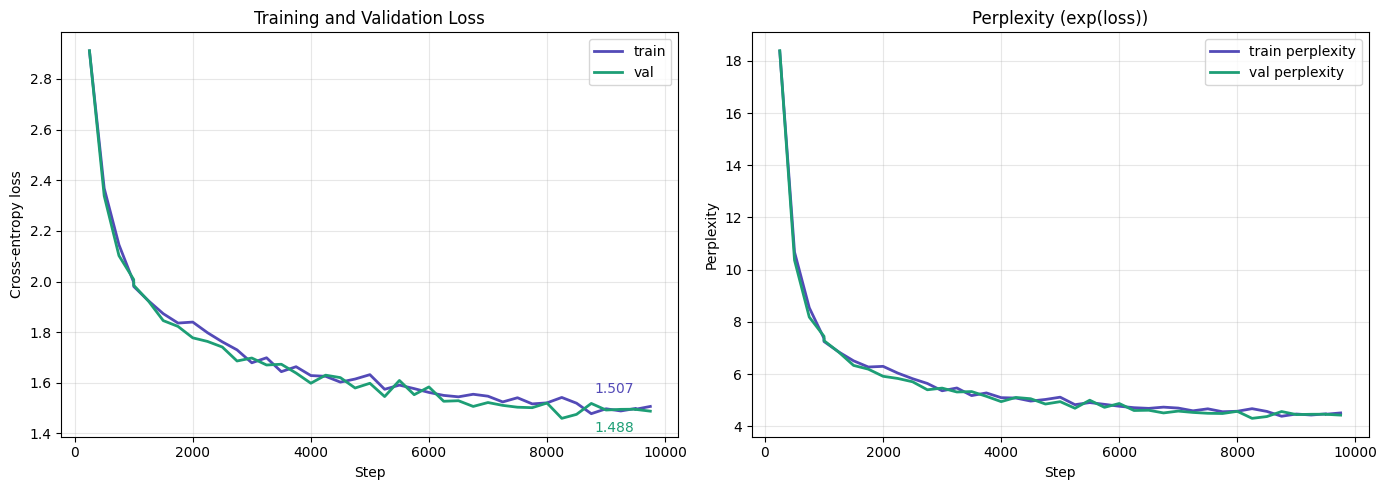

Saved to /kaggle/working/loss_curve.png
Final train loss: 1.5066 (perplexity 4.5)
Final val   loss: 1.4879 (perplexity 4.4)


In [8]:
# ═══════════════════════════════════════════════════════════════════
# CELL 9 — Plot loss curve
# ═══════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt, torch, glob, os

# load losses from latest checkpoint
ckpts = sorted(glob.glob(os.path.join(config['ckpt_dir'], '*.pt')))
assert ckpts, "No checkpoints found"
ckpt   = torch.load(ckpts[-1], map_location='cpu')
losses = ckpt['losses']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# loss curves
ax1.plot(losses['steps'], losses['train'], label='train', color='#534AB7', linewidth=2)
ax1.plot(losses['steps'], losses['val'],   label='val',   color='#1D9E75', linewidth=2)
ax1.set_xlabel('Step')
ax1.set_ylabel('Cross-entropy loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)
# annotate final values
if losses['train']:
    ax1.annotate(f"{losses['train'][-1]:.3f}",
        xy=(losses['steps'][-1], losses['train'][-1]),
        xytext=(-40, 10), textcoords='offset points', color='#534AB7')
    ax1.annotate(f"{losses['val'][-1]:.3f}",
        xy=(losses['steps'][-1], losses['val'][-1]),
        xytext=(-40, -15), textcoords='offset points', color='#1D9E75')

# perplexity = exp(loss) — more intuitive metric
# perplexity of 10 means the model is as uncertain as choosing between 10 options
import math
ax2.plot(losses['steps'], [math.exp(l) for l in losses['train']],
         label='train perplexity', color='#534AB7', linewidth=2)
ax2.plot(losses['steps'], [math.exp(l) for l in losses['val']],
         label='val perplexity',   color='#1D9E75', linewidth=2)
ax2.set_xlabel('Step')
ax2.set_ylabel('Perplexity')
ax2.set_title('Perplexity (exp(loss))')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to /kaggle/working/loss_curve.png")
if losses['train']:
    print(f"Final train loss: {losses['train'][-1]:.4f} "
          f"(perplexity {math.exp(losses['train'][-1]):.1f})")
    print(f"Final val   loss: {losses['val'][-1]:.4f} "
          f"(perplexity {math.exp(losses['val'][-1]):.1f})")

# SFT 

In [9]:
# run this in Kaggle if you haven't already
import shutil, glob
ckpts = sorted(glob.glob('/kaggle/working/checkpoints/*.pt'))
shutil.copy(ckpts[-1], '/kaggle/working/pretrained_base.pt')
print("Done")

Done


In [13]:
# Recovery Cell A — run this after any kernel restart
import torch, math
import torch.nn as nn
import torch.nn.functional as F

# paste your full model definition here
# (RMSNorm, precompute_freqs, apply_rope, CausalSelfAttention, SwiGLU, Block, NanoGPT)
# OR if you have it saved as a file:
# exec(open('/kaggle/working/model.py').read())

# config must match what you trained
config = dict(
    vocab_size  = 50257,
    d_model     = 512,
    n_heads     = 8,
    n_layers    = 6,
    max_seq     = 256,
    dropout     = 0.1,
    device      = 'cuda' if torch.cuda.is_available() else 'cpu',
    dtype       = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16,
)

device = config['device']
model  = NanoGPT(
    vocab_size = config['vocab_size'],
    d_model    = config['d_model'],
    n_heads    = config['n_heads'],
    n_layers   = config['n_layers'],
    max_seq    = config['max_seq'],
    dropout    = config['dropout'],
).to(device)

print(f"Model created: {sum(p.numel() for p in model.parameters())/1e6:.1f}M params")
print(f"Device: {device}")

Model created: 45.0M params
Device: cuda


In [14]:
# Recovery Cell B — check checkpoint is on disk
import os, glob

ckpts = sorted(glob.glob('/kaggle/working/checkpoints/*.pt'))
print(f"Pretraining checkpoints: {ckpts}")

pretrain_path = '/kaggle/working/pretrained_base.pt'
if os.path.exists(pretrain_path):
    print(f"pretrained_base.pt exists ✓ ({os.path.getsize(pretrain_path)/1e6:.0f}MB)")
else:
    print("pretrained_base.pt NOT FOUND")
    if ckpts:
        import shutil
        shutil.copy(ckpts[-1], pretrain_path)
        print(f"Copied {ckpts[-1]} → {pretrain_path} ✓")
    else:
        print("ERROR: No checkpoints found — pretraining must be re-run")

Pretraining checkpoints: ['/kaggle/working/checkpoints/ckpt_step_009000.pt', '/kaggle/working/checkpoints/ckpt_step_009500.pt', '/kaggle/working/checkpoints/ckpt_step_010000.pt']
pretrained_base.pt exists ✓ (540MB)


In [18]:
"""
SFT NOTEBOOK CELLS — paste into Kaggle after pretraining cells
==============================================================
Run cells in order. Assumes:
  - model (NanoGPT) is defined from pretraining cells
  - config dict exists
  - pretrained_base.pt saved at /kaggle/working/pretrained_base.pt
"""
 
 
# ═══════════════════════════════════════════════════════════════════
# SFT CELL 1 — Download Alpaca + build dataset
# ═══════════════════════════════════════════════════════════════════

import torch
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
import tiktoken, os
 
enc = tiktoken.get_encoding("gpt2")
 
# ── download Alpaca ───────────────────────────────────────────────
print("Loading Alpaca (52k instruction pairs)...")
alpaca  = load_dataset("tatsu-lab/alpaca", split="train")
n_val   = int(len(alpaca) * 0.05)       # 5% validation
n_train = len(alpaca) - n_val
print(f"Train: {n_train:,} | Val: {n_val:,}")
print(f"\\nExample:")
print(f"  instruction: {alpaca[0]['instruction']}")
print(f"  output:      {alpaca[0]['output'][:80]}...")
 
 
# ── SFT Dataset with loss masking ────────────────────────────────
class SFTDataset(Dataset):
    def __init__(self, data, enc, max_seq=512):
        self.max_seq  = max_seq
        self.examples = []
        skipped = 0
        for item in data:
            tokens, mask = self._format(item, enc)
            if tokens is None:
                skipped += 1
                continue
            self.examples.append((tokens, mask))
        print(f"SFTDataset: {len(self.examples):,} examples "
              f"({skipped:,} skipped — too long)")
 
    def _format(self, item, enc):
        # build prompt (user turn) — everything up to <|assistant|>
        prompt   = "<|user|>\\n" + item["instruction"]
        if item["input"].strip():
            prompt += "\\n" + item["input"]   # optional extra context
        prompt  += "\\n<|assistant|>\\n"
 
        # build response (what model should generate)
        response = item["output"] + "<|endoftext|>"
 
        # encode SEPARATELY so we know the boundary for the mask
        prompt_toks   = enc.encode(prompt,   allowed_special="all")
        response_toks = enc.encode(response, allowed_special="all")
        tokens        = prompt_toks + response_toks
 
        if len(tokens) > self.max_seq:
            return None, None   # drop examples that are too long
 
        # loss mask: 0=ignore prompt, 1=train on response
        mask = [0] * len(prompt_toks) + [1] * len(response_toks)
        return tokens, mask
 
    def __len__(self):
        return len(self.examples)
 
    def __getitem__(self, idx):
        tokens, mask = self.examples[idx]
        tokens = torch.tensor(tokens, dtype=torch.long)
        mask   = torch.tensor(mask,   dtype=torch.long)
        # shift by 1: x=input, y=next-token target, m=mask aligned with y
        x = tokens[:-1]
        y = tokens[1:]
        m = mask[1:]     # shift mask to align with y, not x
        return x, y, m
 
 
def collate_fn(batch):
    """Pad variable-length examples to longest in batch."""
    xs, ys, ms = zip(*batch)
    maxlen = max(x.size(0) for x in xs)
    xp = torch.zeros(len(xs), maxlen, dtype=torch.long)
    yp = torch.full((len(ys), maxlen), -1, dtype=torch.long)  # -1 = ignore_index
    mp = torch.zeros(len(ms), maxlen, dtype=torch.long)
    for i, (x, y, m) in enumerate(zip(xs, ys, ms)):
        T = x.size(0)
        xp[i,:T] = x
        yp[i,:T] = y
        mp[i,:T] = m
    return xp, yp, mp
 
 
# build dataloaders
train_data = alpaca.select(range(n_train))
val_data   = alpaca.select(range(n_train, len(alpaca)))
 
train_sft_ds = SFTDataset(train_data, enc, max_seq=256)
val_sft_ds   = SFTDataset(val_data,   enc, max_seq=256)
 
train_sft_loader = DataLoader(train_sft_ds, batch_size=8,
    shuffle=True,  collate_fn=collate_fn, num_workers=2, pin_memory=True)
val_sft_loader   = DataLoader(val_sft_ds,   batch_size=8,
    shuffle=False, collate_fn=collate_fn, num_workers=2, pin_memory=True)
 
print(f"\\nTrain batches: {len(train_sft_loader)}")
print(f"Val   batches: {len(val_sft_loader)}")
 
# ── verify mask is working ────────────────────────────────────────
x_sample, y_sample, m_sample = next(iter(train_sft_loader))
print(f"\\nBatch shapes: x={x_sample.shape} y={y_sample.shape} mask={m_sample.shape}")
print(f"Mask values: {m_sample[0].tolist()[:30]}...")
n_prompt   = (m_sample[0] == 0).sum().item()
n_response = (m_sample[0] == 1).sum().item()
print(f"Example 0: {n_prompt} prompt tokens masked, {n_response} response tokens active")

Loading Alpaca (52k instruction pairs)...
Train: 49,402 | Val: 2,600
\nExample:
  instruction: Give three tips for staying healthy.
  output:      1.Eat a balanced diet and make sure to include plenty of fruits and vegetables. ...
SFTDataset: 48,378 examples (1,024 skipped — too long)
SFTDataset: 2,539 examples (61 skipped — too long)
\nTrain batches: 6048
Val   batches: 318
\nBatch shapes: x=torch.Size([8, 245]) y=torch.Size([8, 245]) mask=torch.Size([8, 245])
Mask values: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]...
Example 0: 32 prompt tokens masked, 213 response tokens active


In [19]:
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast
import math, time, glob, os

sft_config = dict(
    pretrain_ckpt  = "/kaggle/working/pretrained_base.pt",
    ckpt_dir       = "/kaggle/working/sft_checkpoints",
    out_model      = "/kaggle/working/sft_model.pt",
    epochs         = 3,
    learning_rate  = 2e-5,
    min_lr         = 2e-6,
    warmup_steps   = 50,
    weight_decay   = 0.01,
    grad_clip      = 1.0,
    grad_accum     = 4,
    log_interval   = 20,
    eval_interval  = 100,
    ckpt_interval  = 200,
)
os.makedirs(sft_config["ckpt_dir"], exist_ok=True)
device = config["device"]
dtype  = config["dtype"]


def masked_cross_entropy(logits, targets, mask):
    B, T, V = logits.shape
    masked_targets = targets.clone()
    masked_targets[mask == 0] = -1
    return F.cross_entropy(
        logits.view(-1, V),
        masked_targets.view(-1),
        ignore_index=-1,
    )


def get_sft_lr(step, total_steps):
    lr, min_lr = sft_config["learning_rate"], sft_config["min_lr"]
    if step < sft_config["warmup_steps"]:
        return lr * step / max(1, sft_config["warmup_steps"])
    if step >= total_steps:
        return min_lr
    ratio = (step - sft_config["warmup_steps"]) / max(1, total_steps - sft_config["warmup_steps"])
    return min_lr + 0.5 * (1 + math.cos(math.pi * ratio)) * (lr - min_lr)


# load pretrained weights
print("Loading pretrained model...")
assert os.path.exists(sft_config["pretrain_ckpt"]), (
    "Pretrained checkpoint not found. Run: "
    "shutil.copy(ckpts[-1], '/kaggle/working/pretrained_base.pt')"
)
ckpt      = torch.load(sft_config["pretrain_ckpt"], map_location=device)
raw_model = model._orig_mod if hasattr(model, "_orig_mod") else model
raw_model.load_state_dict(ckpt["model"])
print(f"Loaded from pretraining step {ckpt.get('step', '?')} ✓")


# fresh optimizer at lower LR — don't reuse pretrain optimizer
# pretrain momentum would cause large harmful updates at SFT start
decay_params    = [p for n, p in raw_model.named_parameters() if p.dim() >= 2]
no_decay_params = [p for n, p in raw_model.named_parameters() if p.dim() < 2]
sft_optimizer   = torch.optim.AdamW([
    {"params": decay_params,    "weight_decay": sft_config["weight_decay"]},
    {"params": no_decay_params, "weight_decay": 0.0},
], lr=sft_config["learning_rate"], betas=(0.9, 0.95),
   fused=(device == "cuda"))
scaler = GradScaler()


# training loop
steps_per_epoch = len(train_sft_loader)
total_steps     = sft_config["epochs"] * steps_per_epoch
sft_losses      = {"train": [], "val": [], "steps": []}
global_step     = 0

print(f"\nSFT Training")
print(f"Epochs: {sft_config['epochs']} | Steps/epoch: {steps_per_epoch} | Total: {total_steps}")
print(f"Effective batch size: {8 * sft_config['grad_accum']}")
print("-" * 65)

model.train()
t0 = time.time()

for epoch in range(sft_config["epochs"]):
    print(f"\n── Epoch {epoch+1}/{sft_config['epochs']} ──")

    for batch_idx, (x, y, mask) in enumerate(train_sft_loader):
        x, y, mask = x.to(device), y.to(device), mask.to(device)

        lr = get_sft_lr(global_step, total_steps)
        for g in sft_optimizer.param_groups:
            g["lr"] = lr

        sft_optimizer.zero_grad(set_to_none=True)
        with autocast(dtype=dtype):
            logits, _ = model(x)
            loss = masked_cross_entropy(logits, y, mask)
            loss = loss / sft_config["grad_accum"]

        scaler.scale(loss).backward()

        if (batch_idx + 1) % sft_config["grad_accum"] == 0:
            scaler.unscale_(sft_optimizer)
            grad_norm = torch.nn.utils.clip_grad_norm_(
                model.parameters(), sft_config["grad_clip"])
            scaler.step(sft_optimizer)
            scaler.update()

        actual_loss = loss.item() * sft_config["grad_accum"]

        if global_step % sft_config["log_interval"] == 0:
            dt = (time.time() - t0) * 1000
            t0 = time.time()
            n_active = mask.sum().item()
            print(f"  step {global_step:4d} | loss {actual_loss:.4f} | "
                  f"lr {lr:.1e} | active_toks {n_active:4d} | {dt:.0f}ms")

        if global_step % sft_config["eval_interval"] == 0 and global_step > 0:
            model.eval()
            val_losses = []
            with torch.no_grad():
                for i, (vx, vy, vm) in enumerate(val_sft_loader):
                    if i >= 20:
                        break
                    vx, vy, vm = vx.to(device), vy.to(device), vm.to(device)
                    with autocast(dtype=dtype):
                        vl, _ = model(vx)
                        val_losses.append(masked_cross_entropy(vl, vy, vm).item())
            val_loss = sum(val_losses) / len(val_losses)
            sft_losses["train"].append(actual_loss)
            sft_losses["val"].append(val_loss)
            sft_losses["steps"].append(global_step)
            print(f"  EVAL step {global_step} | val_loss {val_loss:.4f}")
            model.train()

        if global_step % sft_config["ckpt_interval"] == 0 and global_step > 0:
            raw = model._orig_mod if hasattr(model, "_orig_mod") else model
            path = f"{sft_config['ckpt_dir']}/sft_{global_step:05d}.pt"
            torch.save({
                "step": global_step, "epoch": epoch,
                "model": raw.state_dict(),
                "optimizer": sft_optimizer.state_dict(),
                "losses": sft_losses,
            }, path)
            for old in sorted(glob.glob(f"{sft_config['ckpt_dir']}/*.pt"))[:-3]:
                os.remove(old)
            print(f"  → Checkpoint saved: step {global_step}")

        global_step += 1

# save final model
raw = model._orig_mod if hasattr(model, "_orig_mod") else model
torch.save({
    "model": raw.state_dict(),
    "model_config": config,
    "losses": sft_losses,
    "step": global_step,
}, sft_config["out_model"])
print(f"\nSFT complete! Saved to {sft_config['out_model']}")

Loading pretrained model...
Loaded from pretraining step 10000 ✓

SFT Training
Epochs: 3 | Steps/epoch: 6048 | Total: 18144
Effective batch size: 32
-----------------------------------------------------------------

── Epoch 1/3 ──


/tmp/ipykernel_58/3707903581.py:67: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_58/3707903581.py:95: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=dtype):


  step    0 | loss 7.3874 | lr 0.0e+00 | active_toks  228 | 314ms
  step   20 | loss 6.2927 | lr 8.0e-06 | active_toks  553 | 3206ms
  step   40 | loss 7.5402 | lr 1.6e-05 | active_toks  294 | 3120ms
  step   60 | loss 6.4047 | lr 2.0e-05 | active_toks  408 | 3444ms
  step   80 | loss 6.9355 | lr 2.0e-05 | active_toks  357 | 3343ms
  step  100 | loss 6.0203 | lr 2.0e-05 | active_toks  487 | 3668ms


/tmp/ipykernel_58/3707903581.py:126: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(dtype=dtype):


  EVAL step 100 | val_loss 6.4526
  step  120 | loss 5.0873 | lr 2.0e-05 | active_toks  319 | 4460ms
  step  140 | loss 5.8944 | lr 2.0e-05 | active_toks  300 | 3268ms
  step  160 | loss 6.0397 | lr 2.0e-05 | active_toks  437 | 3306ms
  step  180 | loss 5.1524 | lr 2.0e-05 | active_toks  376 | 3216ms
  step  200 | loss 5.9836 | lr 2.0e-05 | active_toks  394 | 3213ms
  EVAL step 200 | val_loss 6.2344
  → Checkpoint saved: step 200
  step  220 | loss 4.8247 | lr 2.0e-05 | active_toks  427 | 6082ms
  step  240 | loss 6.8393 | lr 2.0e-05 | active_toks  346 | 3447ms
  step  260 | loss 6.1548 | lr 2.0e-05 | active_toks  575 | 3407ms
  step  280 | loss 6.1125 | lr 2.0e-05 | active_toks  718 | 3450ms
  step  300 | loss 6.1335 | lr 2.0e-05 | active_toks  267 | 3449ms
  EVAL step 300 | val_loss 6.1432
  step  320 | loss 5.7360 | lr 2.0e-05 | active_toks  233 | 4645ms
  step  340 | loss 5.8387 | lr 2.0e-05 | active_toks  498 | 4080ms
  step  360 | loss 4.4505 | lr 2.0e-05 | active_toks  287 | 411

In [20]:
test_prompts = [
    "What is the capital of France?",
    "Write a haiku about rain.",
    "Explain what a computer does in one sentence.",
]

for prompt in test_prompts:
    print(f"User: {prompt}")
    print(f"Assistant: {chat(prompt)}")
    print("-" * 40)

User: What is the capital of France?


NameError: name 'chat' is not defined